# Quality toolbox

In [1]:
# Import library needed
#import functions
import numpy as np
import matplotlib.pyplot as plt

from NEUREQUA import *


from NEUREQUA import cognitive_module as cog 
from NEUREQUA import quality_module as quality

## Load data and parameters

In [2]:
# Parameters of the session you analyze

# Name or number of the subject you analyze
sub = 'sub-3'
# Name of the session you analyze
sess = 'sitcom'

In [3]:
# Path to data - This is the only thing you have to change to run the script


# Path where your micro data are stored (.dat, .medd, .nsX, .ncs)
dataFolder=r'C:\Users\dornier\PhD\Divers\Test_Data_Grenoble\sub-03\J3 - Sitcom/'
#dataFolder=r'F:\Screening\database\sub-97\sess-1\ncs/' 

# Path where you want to store figures and results
saveFolder=r'C:\Users\dornier\PhD\Divers\Test_Data_Grenoble\sub-03\J3 - Sitcom/Quality_Data/'

# path to excel file for the RMS tracking, only one excel is used per patient, all RMS data for the SEEG will be trancked on a single file

trackingtbl =r'C:\Users\dornier\PhD\Divers\Test_Data_Grenoble/tracking_data_grenoble.xlsx'


In [4]:
# Load data 
# Give the path folder where the files of micro-electrodes are stored
raw_data, data = quality.load_raw_data(dataFolder,dtype='ncs',length=5)


Checking files in C:\Users\dornier\PhD\Divers\Test_Data_Grenoble\sub-03\J3 - Sitcom
Ignoring .ncs files:

Checking for temporal discontinuities in Neo data segments.
N = 686 discontinuous Neo segments detected with delta > 4.57763671875e-05 sec. Annotating gaps as BAD_ACQ_SKIP.


In [5]:
# Determine parameters from the recording
sr = int(raw_data.info['sfreq'])
print("Your recording has a sampling rate of: " + str(sr) +" Hz")

Your recording has a sampling rate of: 32768 Hz


In [6]:
duration_min  = int(raw_data.__len__()/sr/60)

print("L'enregistrement a duré : "+str(duration_min)+" minutes")

L'enregistrement a duré : 5 minutes


In [7]:
# Display the name of your electrodes

chRegions = np.array(raw_data.ch_names)
print(chRegions)

['c_tt1' 'c_tt2' 'c_tt3' 'c_tt4' 'c_tt5' 'c_tt6' 'c_tt7' 'c_tt8' 'e_tt1'
 'e_tt2' 'e_tt3' 'e_tt4' 'e_tt5' 'e_tt6' 'e_tt7' 'e_tt8' 'p_tt1' 'p_tt2'
 'p_tt3' 'p_tt4' 'p_tt5' 'p_tt6' 'p_tt7' 'p_tt8' 'v_tt1' 'v_tt2' 'v_tt3'
 'v_tt4' 'v_tt5' 'v_tt6' 'v_tt7' 'v_tt8']


In [8]:
# Re-order channels and data if there is more than two tetrode on a shaft
chRegions, data = quality.reorder_data(chRegions,data)


print(chRegions)

['c_tt1' 'c_tt2' 'c_tt3' 'c_tt4' 'c_tt5' 'c_tt6' 'c_tt7' 'c_tt8' 'e_tt1'
 'e_tt2' 'e_tt3' 'e_tt4' 'e_tt5' 'e_tt6' 'e_tt7' 'e_tt8' 'p_tt1' 'p_tt2'
 'p_tt3' 'p_tt4' 'p_tt5' 'p_tt6' 'p_tt7' 'p_tt8' 'v_tt1' 'v_tt2' 'v_tt3'
 'v_tt4' 'v_tt5' 'v_tt6' 'v_tt7' 'v_tt8']


In [9]:
# Prepare the tracking file

quality.tblprep(trackingtbl,chRegions,sub,sess)

## Quality analysis of the signal

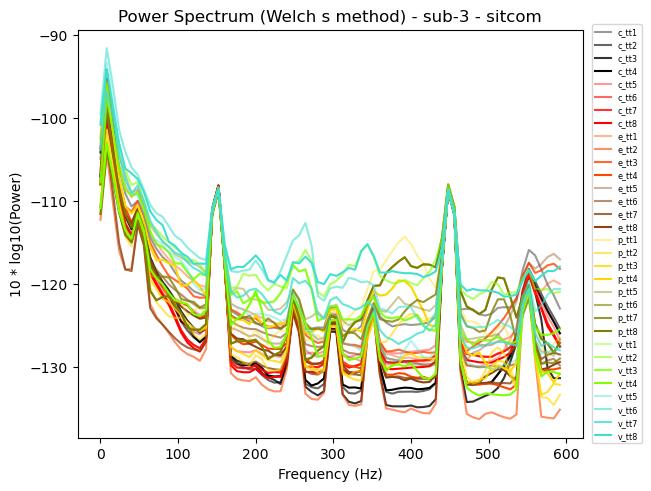

In [10]:
# Get the power spectrum of each channel 
quality.p_welch(data,chRegions,sub,sess,sr,sr_down=4,fr_low=1,fr_high=600,saveFolder=saveFolder,probe_type='Dixi')

In [11]:
# Get the level of noise of the recording for each channel (not displayed in the notebook)
quality.plot_noise(data,sr,chRegions,saveFolder)


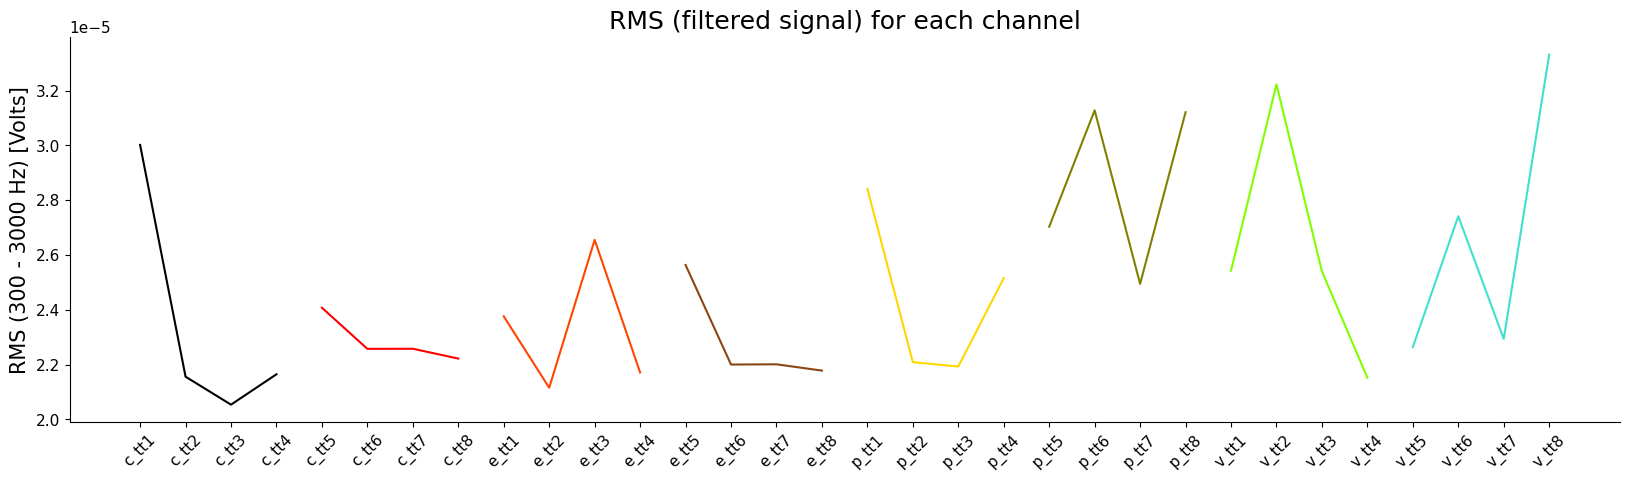

In [12]:
# Compute RMS on filtered signal
quality.rms_signal_filtered(data,trackingtbl,chRegions,sub,sess,fr_low=300,fr_high=3000,sr=sr,saveFolder=saveFolder) 

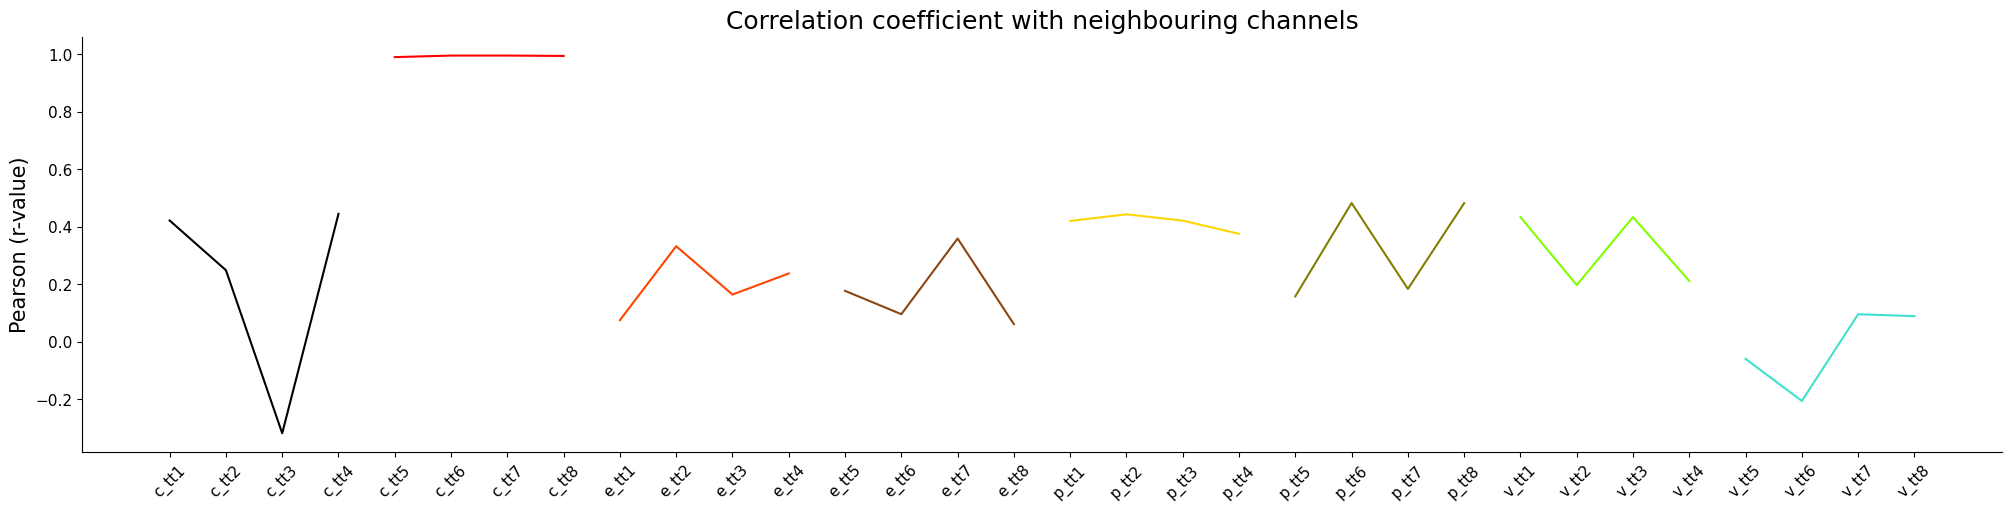

In [13]:
# Compute correlation between neighbouring channels

correlation = quality.correlation_coefficient(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

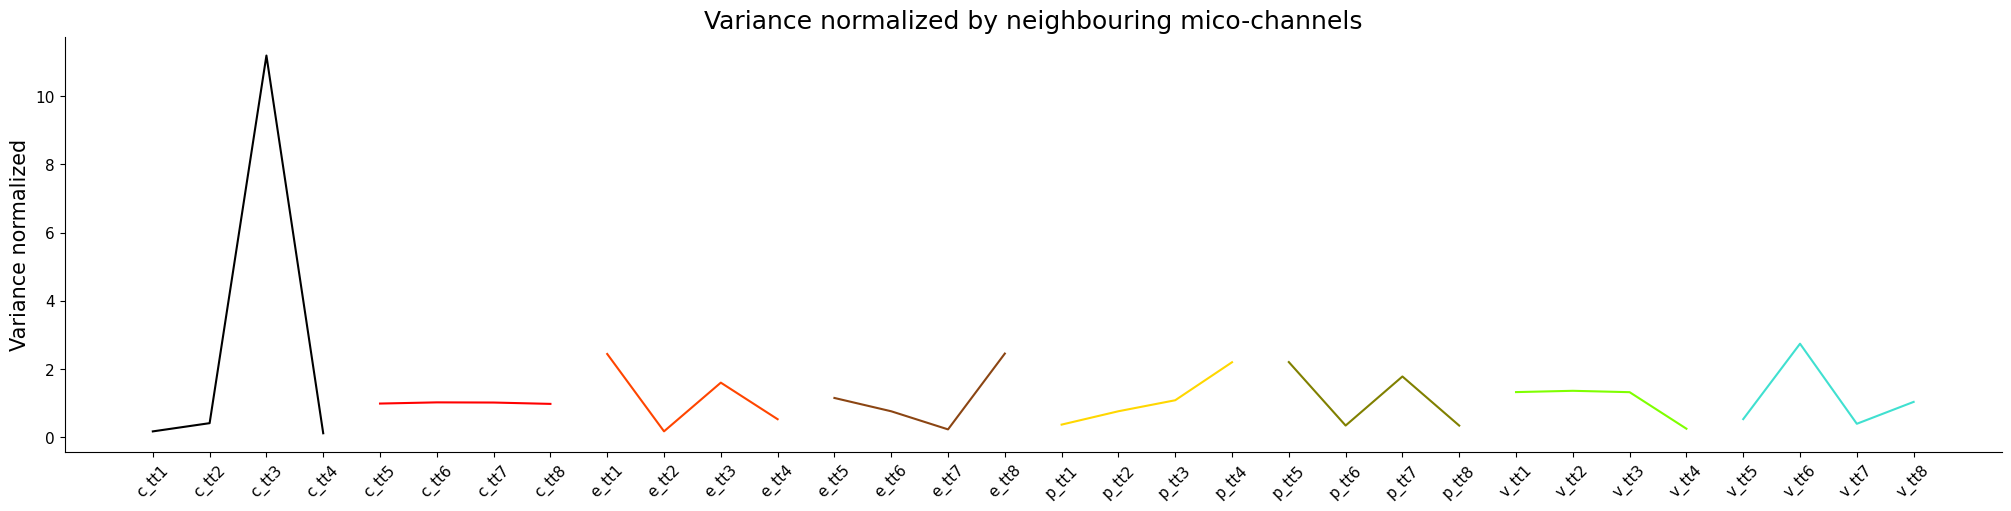

In [14]:
# Compute variance normalized by variance of neighbouring channels
quality.variance_normalized(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

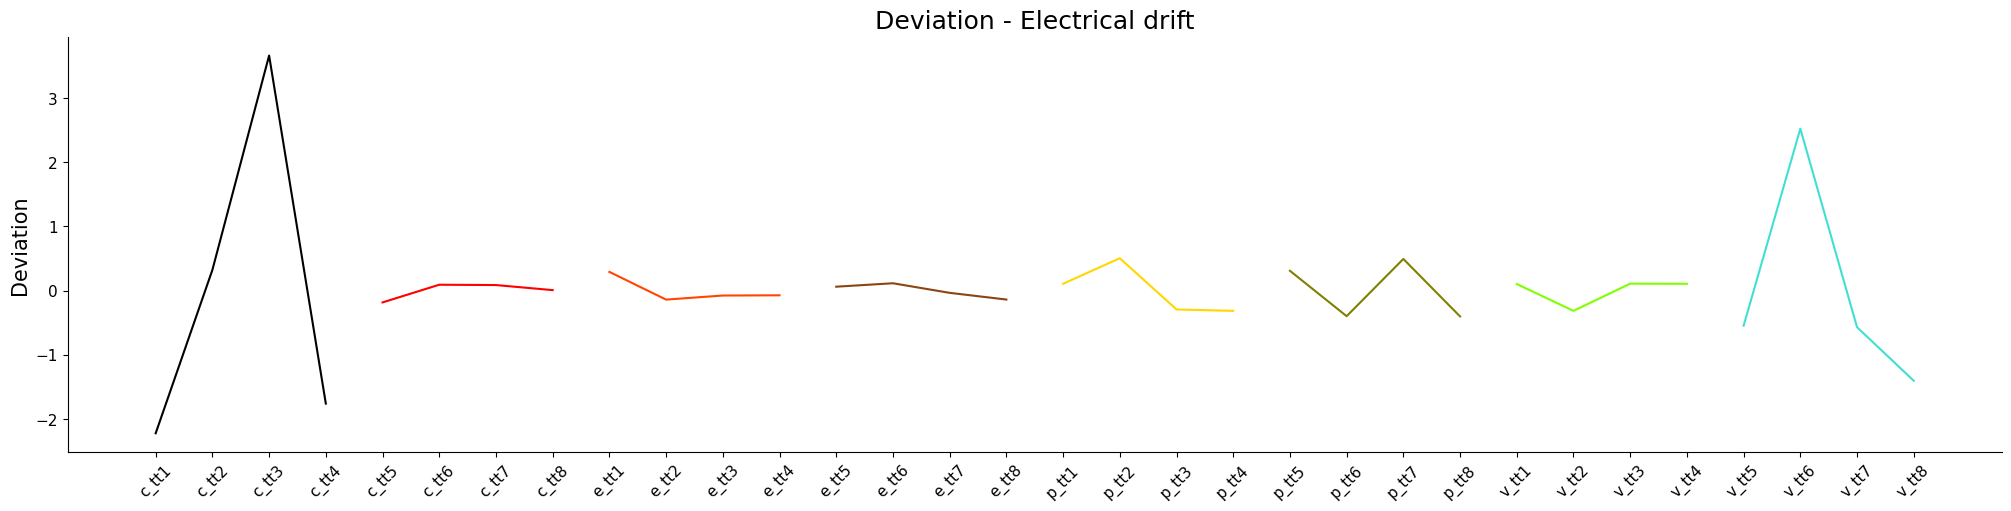

In [15]:
quality.deviation(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

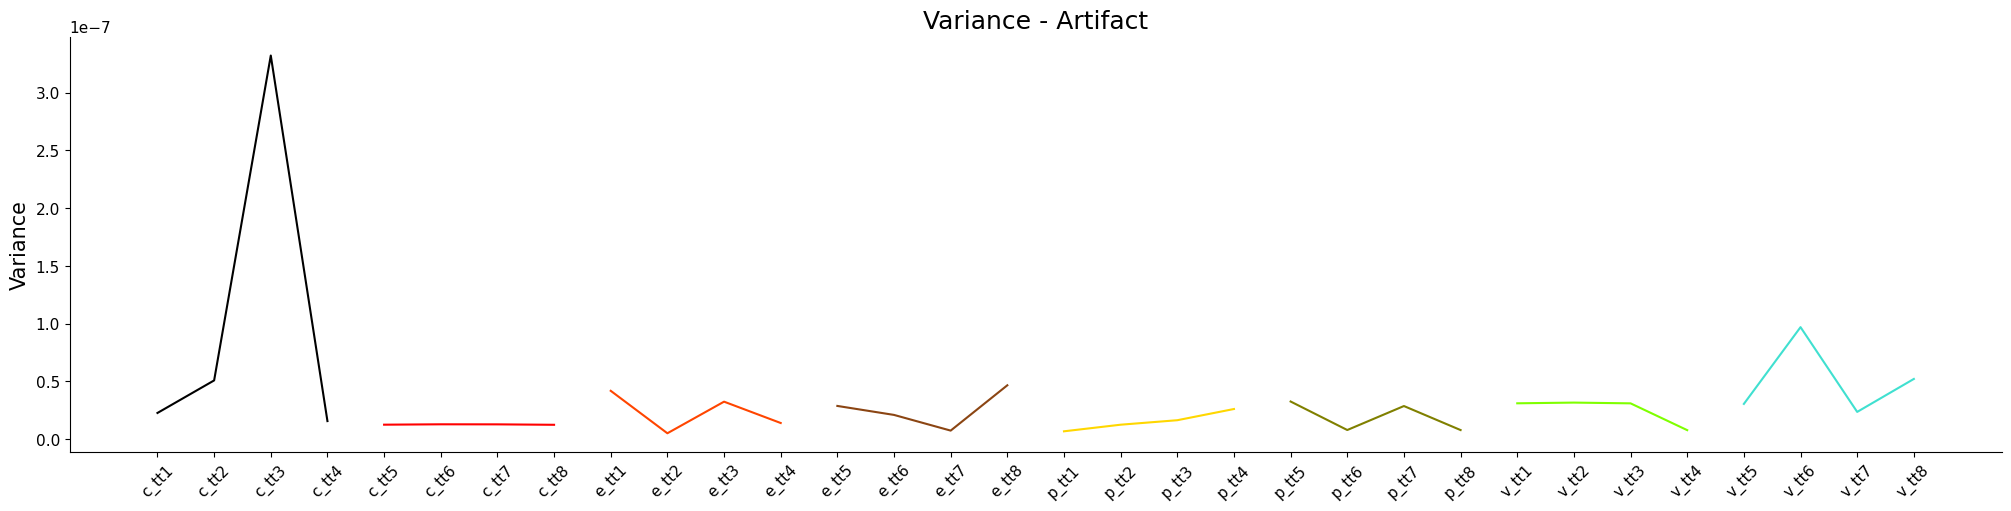

In [16]:
quality.variance(data,chRegions,saveFolder,trackingtbl,sub,sess)

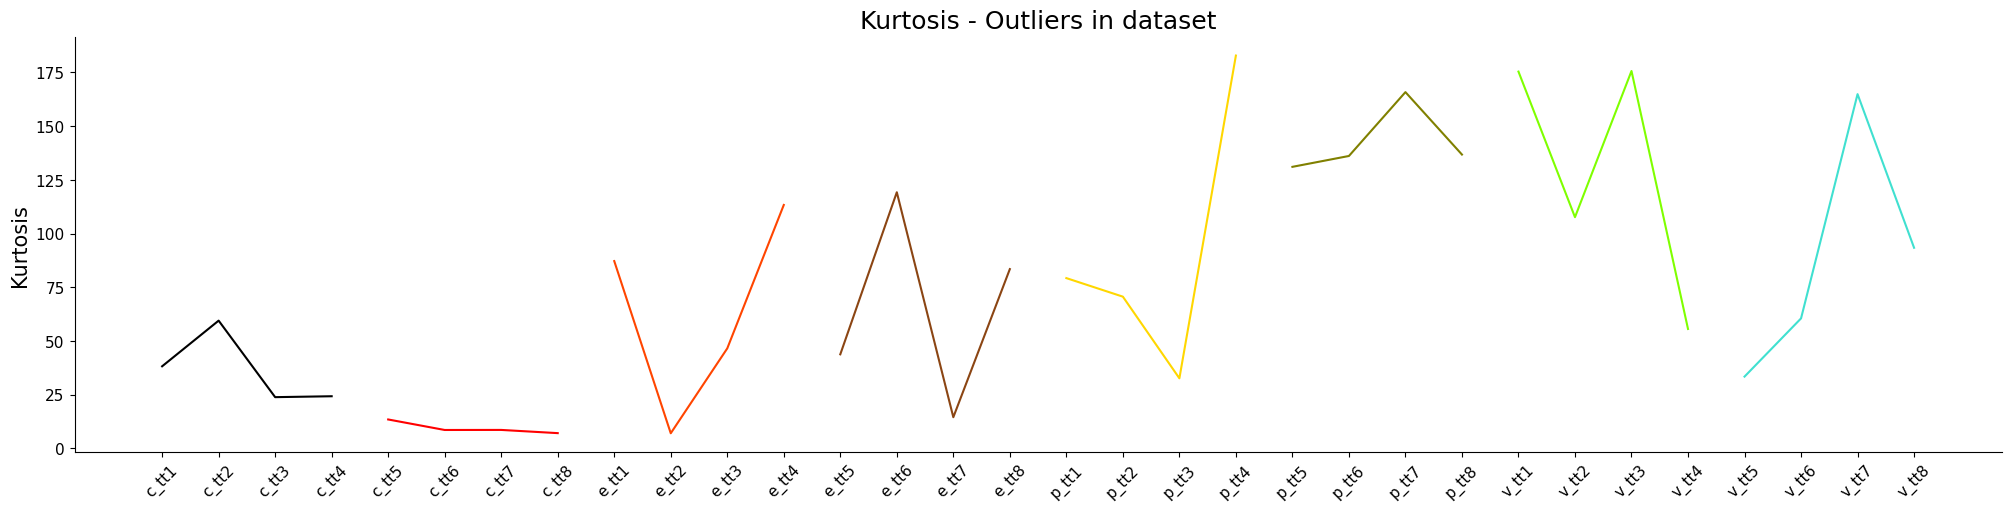

In [17]:
quality.kurtosis(data,chRegions,saveFolder,trackingtbl,sub,sess)

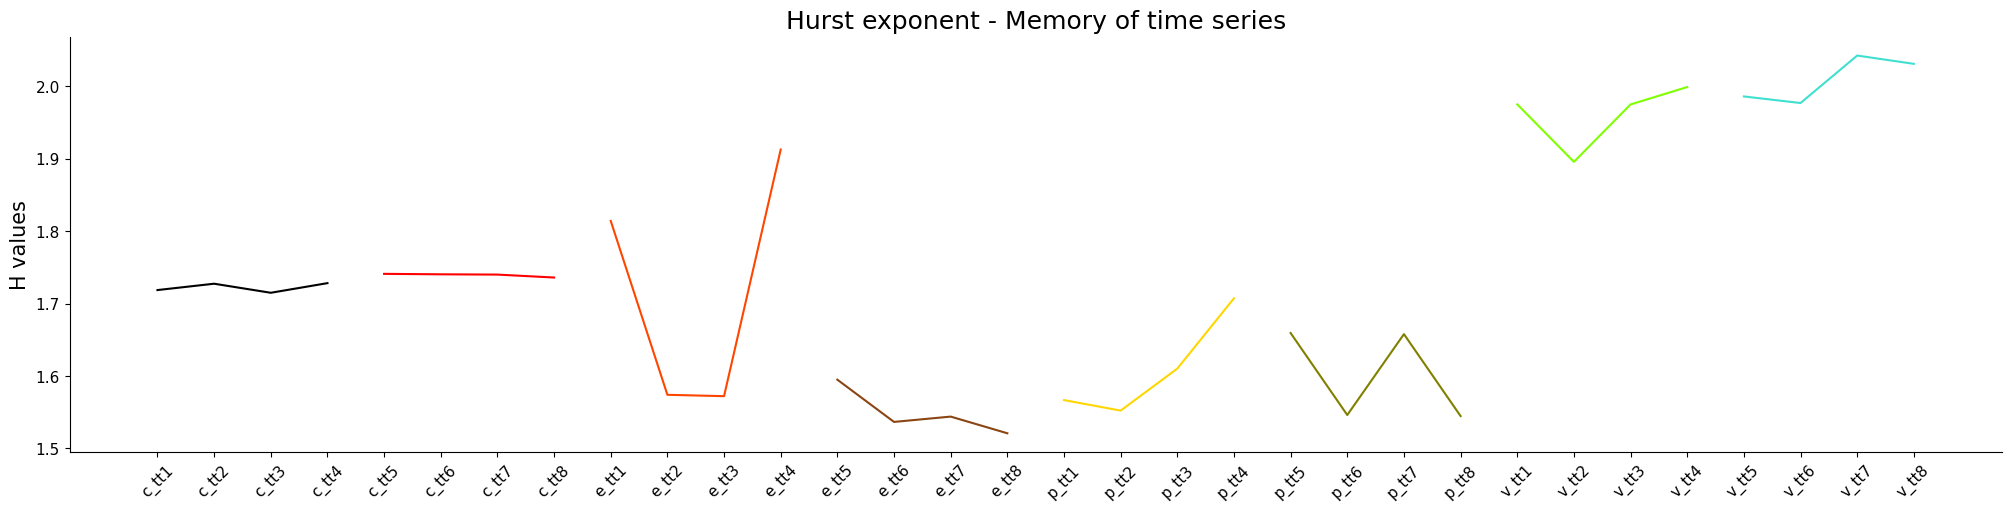

In [37]:
quality.hurst_component(data,chRegions,saveFolder,trackingtbl,sub,sess)

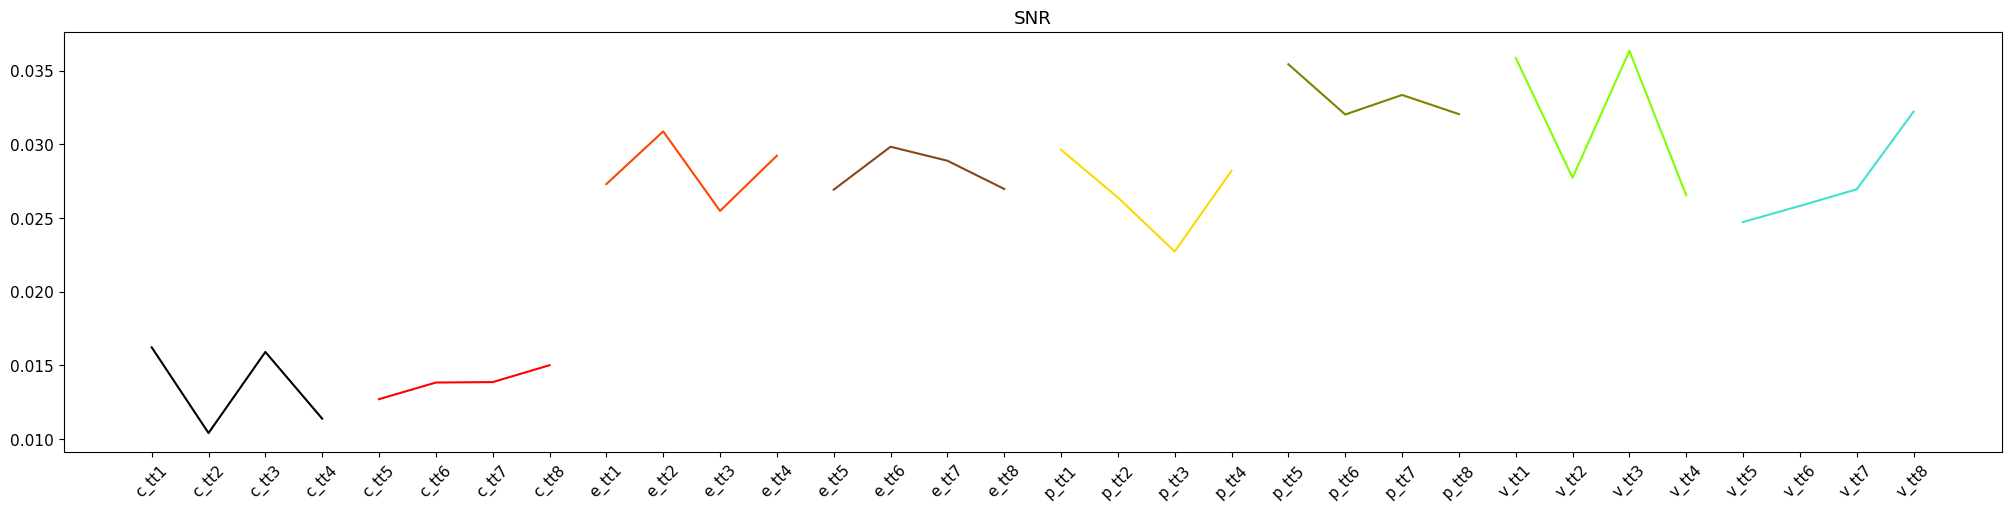

In [38]:
SNR = quality.signaltonoise(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [33]:
# Test on artefacts

from NEUREQUA import artefact_detections

test = list()

for iTetrode in range(int(data.shape[0]/4)):
    num_canalTetrode = (iTetrode*4,iTetrode*4+1,iTetrode*4+2,iTetrode*4+3)

    test.append(num_canalTetrode)

tetInds = test 

# Movement artefacts
badWins_movement = artefact_detections.detect_movement_artifacts(chTraces=data,chGoodInds=list(range(len(chRegions))),
                                                                tetInds=tetInds,verbose=False,SR=32768)


# Detect subtle artefacts
badWins_subtle = artefact_detections.detect_subtle_artifacts(chTraces=data,chGoodInds=np.array(list(range(len(chRegions)))),
                                                            tetInds= tetInds,chRegs=chRegions,SR=32768,verbose=False)

# Step 3: Merge detected windows using intersection
badWins_final = artefact_detections.get_timeWinsIntersect(badWins_movement, badWins_subtle, data.shape[1])


# Step 4: Print percentage of artefacted signal
artefact_detections.ratio_artefact(data,badWins_final,trackingtbl,sub,sess)

Your recording contains: 9.033069963270064 % of artefacts


# Cognitive analyses of experiment

In [ ]:
# Create epoch objects
epoch = cog.create_epoch(dataFolder,t_min=-1,t_max=1)

NameError: name 'dataFolder' is not defined

In [ ]:
# This step is really long, if you have your own method quicker you should use it
epoch = epoch.get_data()
np.save(r'F:\Screening\database\sub-123\sess-1\epoch/epoch_micro.npy',epoch)

Loading data for 808 events and 65537 original time points ...
137 bad epochs dropped


In [24]:
# If you already created your epoch numpy file load it
epoch_data = np.load(r'F:\Screening\database\sub-123\sess-1\epoch/epoch_micro.npy')

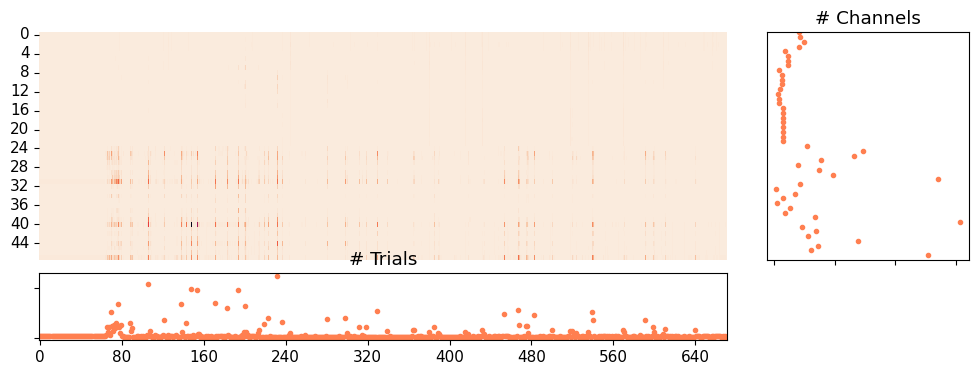

In [26]:
cog.plot_artefact_map(epoch_data=epoch_data,path='C:/Users/dornier/PhD/Quality_Data/')